# A 2 Layer neural network built with only Numpy trained on the Kaggle MNIST digit recognition dataset 


## Set up

In [ ]:
%pip install numpy pandas matplotlib

In [ ]:
%pip install kaggle

In [ ]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 

## Loading and Processing the data 

In [ ]:
df = pd.read_csv("data/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = np.array(df)
m, n = df.shape
np.random.shuffle(df)

df_dev = df[0:1000].T
y_dev = df_dev[0]
x_dev = df_dev[1:n] 
x_dev = x_dev / 255

df_train = df[1000:m].T
x_train = df_train[1 : n] 
x_train = x_train / 255
y_train = df_train[0]

## Model

In [24]:
def init_params():
    w1 = np.random.randn(10, 784) * np.sqrt(2 / 784)
    b1 = np.random.randn(10, 1) 
    w2 = np.random.randn(10, 10)  * np.sqrt(2 / 10)
    b2 = np.random.randn(10, 1) 
    
    return w1, b1, w2, b2

def ReLU(z):
    return np.maximum(0, z)

def softmax(z):
    z_shift = z - np.max(z, axis = 0, keepdims=True)
    return np.exp(z_shift)/ np.sum(np.exp(z_shift), axis=0, keepdims= True)

def forward_prop(w1, b1, w2, b2, x):
    
    z1 = w1.dot(x) + b1
    a1 = ReLU(z1)
    
    z2 = w2.dot(a1) + b2 
    a2 = softmax(z2)
    
    return z1, a1, z2, a2 

def one_hot(y):
    one_hot_y = np.zeros ((y.size, y.max() + 1))
    one_hot_y[np.arange(y.size), y] = 1 
    one_hot_y = one_hot_y.T 
    return one_hot_y

def deriv_ReLU(z):
    return z > 0 

def backprop(z1 , a1, z2, a2, w2, x, y):
    m = y.size
    one_hot_y = one_hot(y)
    dz2 = a2 - one_hot_y 
    dw2 = (1/m) * dz2.dot(a1.T)
    db2 = (1./m) * np.sum(dz2) 
    dz1 = w2.T.dot(dz2) * deriv_ReLU(z1) 
    
    dw1 = (1/m) * dz1.dot(x.T)
    db1= (1./m) * np.sum(dz1) 
    
    return dw1, db1, dw2, db2 

def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha):
     w1 = w1 - alpha*dw1 
     b1 = b1 - alpha*db1
     w2 = w2 - alpha*dw2 
     b2 = b2 - alpha*db2
     
     return w1, b1, w2, b2 

## Training

In [18]:
def get_predictions(a2):
    return np.argmax(a2, 0)

def get_accuracy(predictions, y):
    print(predictions, y)
    return np.sum(predictions == y) / y.size

def gradient_decent(x, y, iterrations, alpha):
    w1, b1, w2, b2 = init_params()
    for i in range(iterrations):
        z1, a1, z2, a2 = forward_prop(w1, b1, w2, b2, x)
        dw1, db1, dw2, db2 = backprop(z1, a1, z2, a2, w2, x, y)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha)
        
        if (i % 10) == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(a2), y))
            
    return w1, b1, w2, b2 

In [27]:
w1, b1, w2, b2 = gradient_decent(x_train, y_train, 100, 0.1)

Iteration:  0
[9 1 6 ... 6 9 6] [3 0 7 ... 4 9 1]
Accuracy:  0.1065609756097561
Iteration:  10
[1 5 6 ... 1 1 1] [3 0 7 ... 4 9 1]
Accuracy:  0.21817073170731707
Iteration:  20
[1 5 5 ... 9 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.36841463414634146
Iteration:  30
[1 5 7 ... 9 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.533609756097561
Iteration:  40
[1 5 7 ... 9 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.6571951219512195
Iteration:  50
[1 5 7 ... 4 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.7184146341463414
Iteration:  60
[1 5 7 ... 4 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.7455121951219512
Iteration:  70
[1 5 7 ... 4 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.7647560975609756
Iteration:  80
[1 5 7 ... 4 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.7801219512195122
Iteration:  90
[1 5 7 ... 4 9 1] [3 0 7 ... 4 9 1]
Accuracy:  0.7916341463414635


## Evaluation 

In [28]:
def make_predictions(x, w1, b1, w2, b2):
    _, _, _, a2 = forward_prop(w1, b1, w2, b2, x)
    predictions = get_predictions(a2)
    return predictions 

def test_predictions(index, w1, b1, w2, b2):
    current_image = x_train[:, index, None]
    prediction = make_predictions(x_train[:, index, None], w1, b1, w2, b2)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation = "nearest")
    plt.show()

## Results

In [37]:
dev_predictions = make_predictions(x_dev, w1, b1, w2, b2)
get_accuracy(dev_predictions, y_dev)

[6 3 5 3 0 4 2 1 8 1 7 9 7 5 2 6 3 3 7 5 8 6 8 0 2 0 8 5 7 3 1 9 9 7 1 6 6
 3 5 8 1 8 2 8 3 3 9 3 1 7 1 0 2 3 9 6 2 7 8 9 7 3 2 9 6 0 4 6 4 9 4 6 3 3
 1 7 9 1 6 0 0 0 4 3 9 8 2 0 2 0 5 6 0 3 3 3 0 2 3 7 1 5 9 4 1 4 3 2 5 1 7
 6 6 7 1 9 7 4 8 4 2 8 5 3 4 1 1 8 0 9 4 5 3 5 1 4 6 4 6 2 1 8 9 3 3 3 3 2
 0 6 1 6 4 2 0 2 2 1 9 0 5 7 7 2 0 6 8 5 7 6 3 0 6 9 0 2 6 3 3 0 4 3 3 0 0
 8 2 1 7 3 5 1 3 9 2 1 7 3 7 8 3 3 9 7 4 1 5 4 5 2 7 5 9 4 0 3 3 6 3 7 6 3
 1 6 6 2 4 3 7 7 9 1 8 4 0 2 5 3 2 1 6 0 5 3 0 8 9 2 6 0 3 9 1 1 1 6 6 1 6
 2 3 2 3 5 8 7 5 1 2 7 5 2 5 5 2 9 9 0 0 1 1 1 8 5 5 0 8 1 9 8 5 7 1 9 3 5
 1 5 5 9 4 8 4 6 5 7 1 5 1 4 8 3 3 5 6 2 6 2 1 1 6 4 3 2 0 5 9 2 3 9 6 6 5
 3 1 1 8 0 3 0 0 1 7 6 2 6 2 2 1 9 4 2 1 8 2 8 9 7 9 1 3 1 9 6 0 0 8 3 0 0
 7 8 4 0 2 7 0 8 3 7 0 6 1 5 3 0 4 3 8 6 7 3 5 4 3 4 7 7 5 3 1 9 8 1 7 0 7
 1 6 3 3 6 8 2 6 0 8 2 7 7 3 9 8 4 1 9 8 5 4 5 9 0 9 0 1 9 3 6 6 0 3 5 6 7
 8 5 0 9 8 7 7 9 8 2 6 0 2 6 7 5 6 5 1 3 3 1 8 0 9 7 9 9 0 8 0 5 0 1 6 5 2
 0 0 6 6 9 7 1 0 4 8 3 1 

np.float64(0.788)

#### Model accuracy is 78.8%

## Sample Predictions

Prediction:  [2]
Label:  3


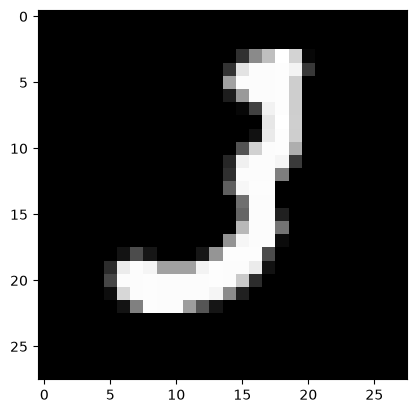

Prediction:  [5]
Label:  5


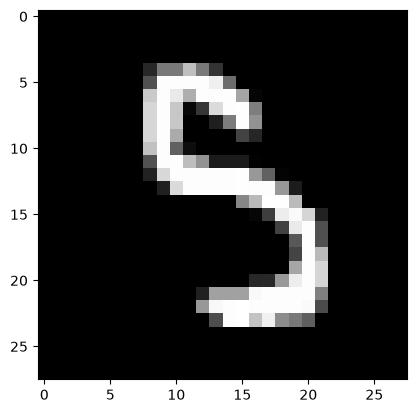

Prediction:  [0]
Label:  0


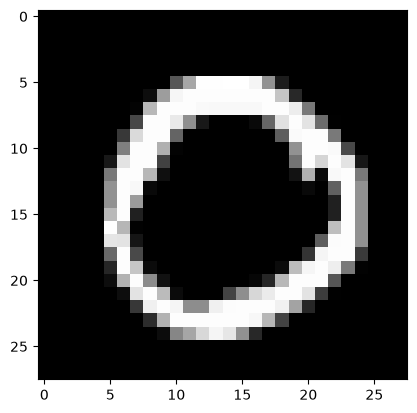

Prediction:  [3]
Label:  3


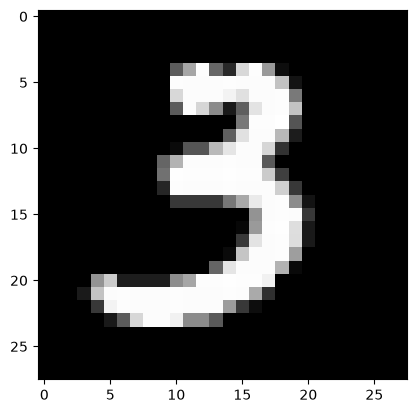

Prediction:  [2]
Label:  3


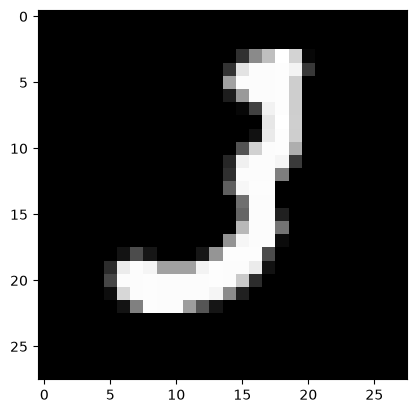

Prediction:  [7]
Label:  7


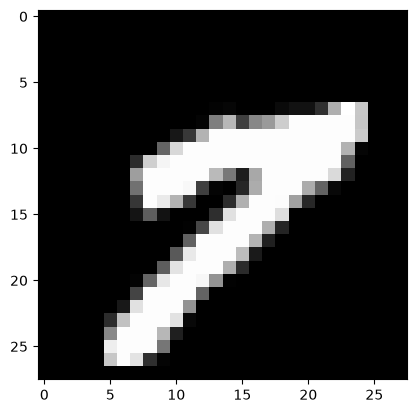

Prediction:  [8]
Label:  8


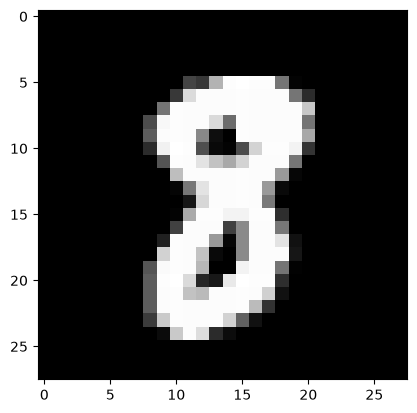

In [39]:
test_predictions(5, w1, b1, w2, b2)
test_predictions(9, w1, b1, w2, b2)
test_predictions(109, w1, b1, w2, b2)
test_predictions(95, w1, b1, w2, b2)
test_predictions(5, w1, b1, w2, b2)
test_predictions(2, w1, b1, w2, b2)
test_predictions(56, w1, b1, w2, b2)